In [ ]:
import warnings

warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

In [ ]:
diabetes = load_diabetes()
dataset = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
dataset['target'] = diabetes.target
dataset.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [ ]:
array = dataset.values
x = array[:, 0:10]
y = array[:, 10]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=7)

num_particoes = 10
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=7)


LR: MSE = 3066.4882 (±612.0550) | RMSE = 55.3759
LASSO: MSE = 3948.9073 (±890.9945) | RMSE = 62.8403
Ridge: MSE = 3566.4345 (±805.5396) | RMSE = 59.7196
KNN: MSE = 3522.1384 (±721.7567) | RMSE = 59.3476
CART: MSE = 6431.2591 (±1584.0491) | RMSE = 80.1951
SVM: MSE = 5285.0871 (±1186.1850) | RMSE = 72.6986


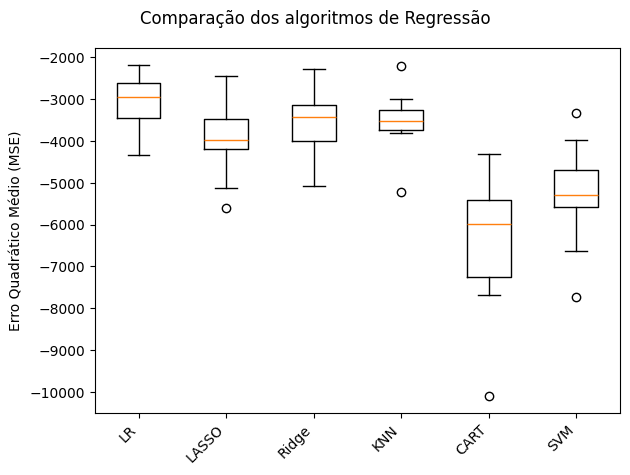

In [ ]:
np.random.seed(7)

models = []
results = []
names = []

models.append(('LR', LinearRegression()))
models.append(('LASSO', Lasso()))
models.append(('Ridge', Ridge()))
models.append(('KNN', KNeighborsRegressor()))
models.append(('CART', DecisionTreeRegressor()))
models.append(('SVM', SVR()))

for name, model in models:
    cv_results = cross_val_score(model, x_train, y_train, cv=kfold, scoring='neg_mean_squared_error')
    results.append(cv_results)
    names.append(name)
    mse = abs(cv_results.mean())
    rmse = np.sqrt(mse)
    msg = '%s: MSE = %.4f (±%.4f) | RMSE = %.4f' % (name, mse, cv_results.std(), rmse)
    print(msg)

fig = plt.figure()
fig.suptitle('Comparação dos algoritmos de Regressão')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names)
plt.xticks(rotation=45, ha='right')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.tight_layout()
plt.show()

In [ ]:
model = LinearRegression()
model.fit(x_train, y_train)
predictions = model.predict(x_test)

mse = mean_squared_error(y_test, predictions)
print('MSE: %.4f' % mse)
print('RMSE: %.4f' % rmse)

MSE: 2966.0495
RMSE: 72.6986


COMPARAÇÃO DE MODELOS DE REGRESSÃO
Modelo                         MSE             RMSE            Std       
--------------------------------------------------------------------------------
Linear Regression              3066.4882        55.3759       612.0550
Lasso                          3948.9073        62.8403       890.9945
Ridge                          3566.4345        59.7196       805.5396
ElasticNet                     6129.2072        78.2893       1278.9750
Bayesian Ridge                 3073.2407        55.4368       624.2621
Huber Regressor                3114.0372        55.8036       628.6146
Theil-Sen                      3122.5159        55.8795       587.6756
Decision Tree                  6767.6216        82.2656       1741.3681
Extra Tree                     6411.0754        80.0692       1605.9502
Random Forest                  3500.1646        59.1622       1059.9421
Extra Trees                    3274.5766        57.2239       926.0114
Gradient Boosting        

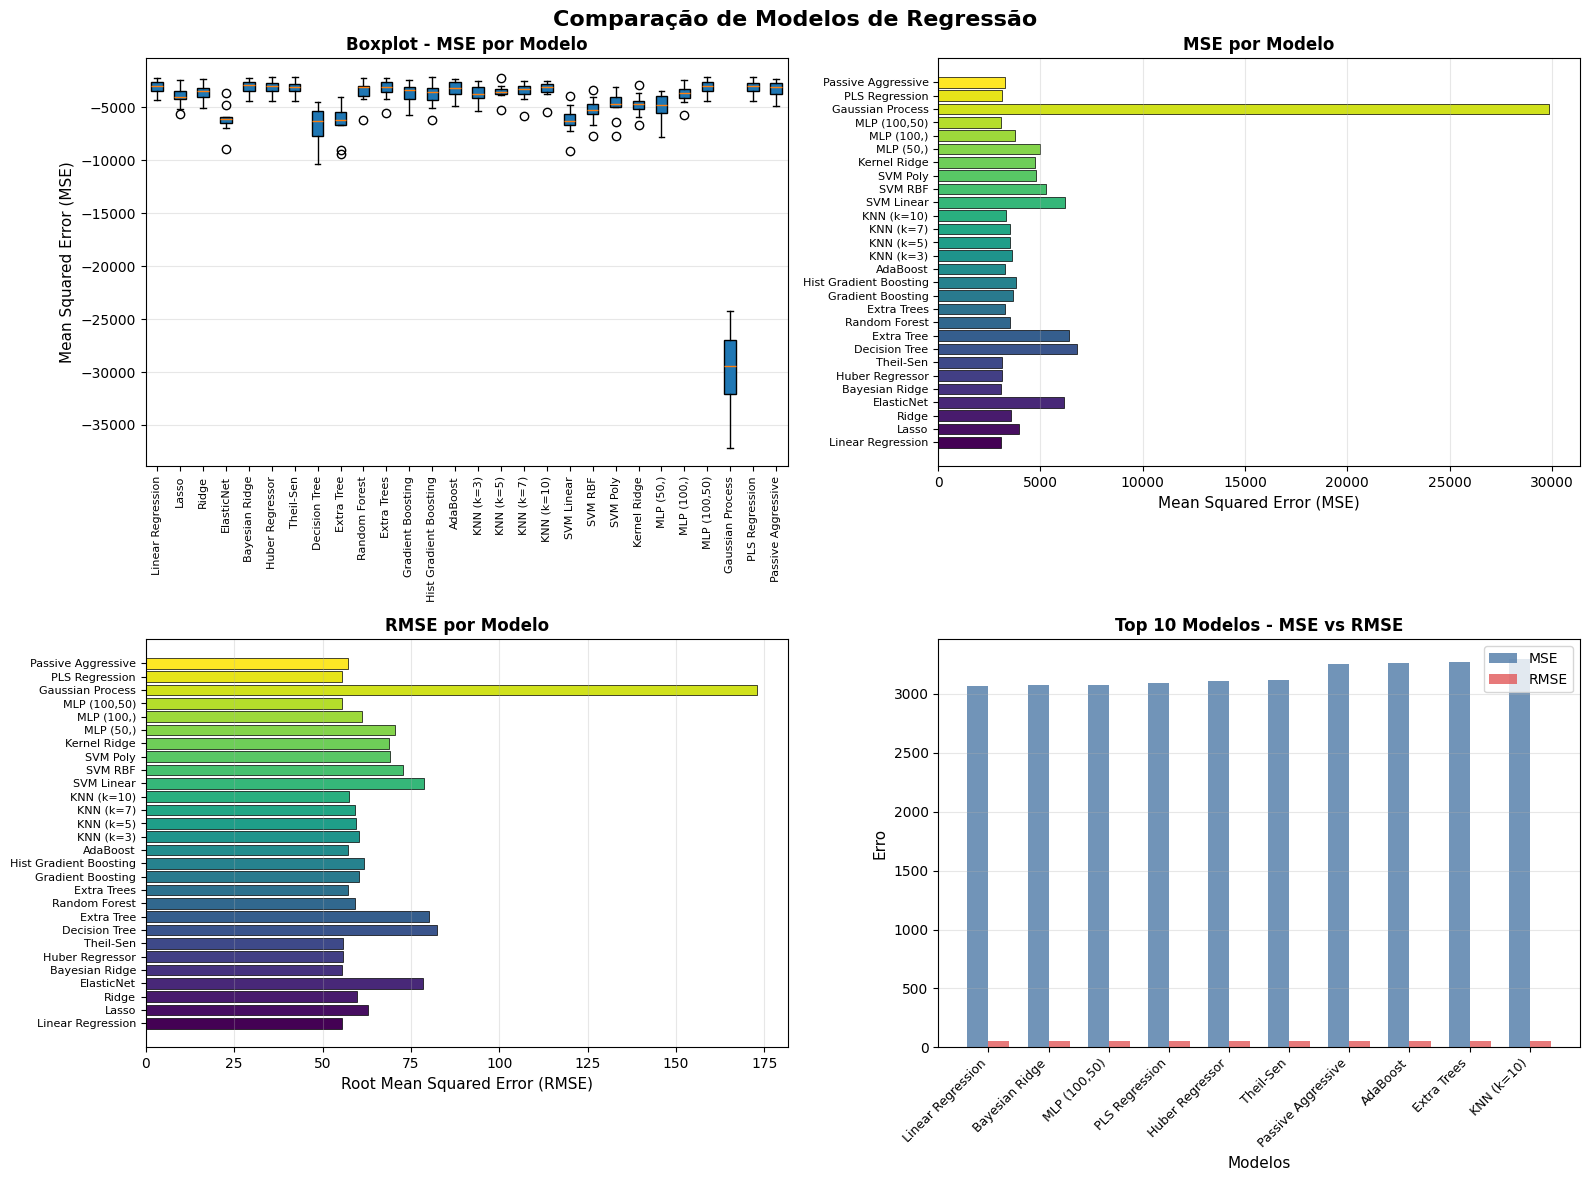

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score

# Modelos originais
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

# NOVOS MODELOS
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.kernel_ridge import KernelRidge
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern
from sklearn.linear_model import BayesianRidge, HuberRegressor, TheilSenRegressor
from sklearn.tree import ExtraTreeRegressor
from sklearn.isotonic import IsotonicRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import PassiveAggressiveRegressor

# Carregar dados
diabetes = load_diabetes()
dataset = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
dataset['target'] = diabetes.target

array = dataset.values
x = array[:, 0:10]
y = array[:, 10]
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=7)

num_particoes = 10
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=7)

np.random.seed(7)

# ============================================
# LISTA COMPLETA DE MODELOS
# ============================================

models = []

# 1. Modelos Lineares (originais + novos)
models.append(('Linear Regression', LinearRegression()))
models.append(('Lasso', Lasso(random_state=7)))
models.append(('Ridge', Ridge(random_state=7)))
models.append(('ElasticNet', ElasticNet(random_state=7)))  # Combina L1 e L2
models.append(('Bayesian Ridge', BayesianRidge()))  # Abordagem bayesiana
models.append(('Huber Regressor', HuberRegressor()))  # Robusto a outliers
models.append(('Theil-Sen', TheilSenRegressor(random_state=7)))  # Robusto a outliers

# 2. Modelos Baseados em Árvores
models.append(('Decision Tree', DecisionTreeRegressor(random_state=7)))
models.append(('Extra Tree', ExtraTreeRegressor(random_state=7)))  # Uma árvore aleatória
models.append(('Random Forest', RandomForestRegressor(n_estimators=100, random_state=7)))
models.append(('Extra Trees', ExtraTreesRegressor(n_estimators=100, random_state=7)))
models.append(('Gradient Boosting', GradientBoostingRegressor(n_estimators=100, random_state=7)))
models.append(('Hist Gradient Boosting', HistGradientBoostingRegressor(random_state=7)))
models.append(('AdaBoost', AdaBoostRegressor(n_estimators=100, random_state=7)))

# 3. Modelos de Distância
models.append(('KNN (k=3)', KNeighborsRegressor(n_neighbors=3)))
models.append(('KNN (k=5)', KNeighborsRegressor(n_neighbors=5)))
models.append(('KNN (k=7)', KNeighborsRegressor(n_neighbors=7)))
models.append(('KNN (k=10)', KNeighborsRegressor(n_neighbors=10)))

# 4. Support Vector Machines
models.append(('SVM Linear', SVR(kernel='linear')))
models.append(('SVM RBF', SVR(kernel='rbf')))
models.append(('SVM Poly', SVR(kernel='poly', degree=3)))
models.append(('Kernel Ridge', KernelRidge(kernel='rbf')))

# 5. Redes Neurais
models.append(('MLP (50,)', MLPRegressor(hidden_layer_sizes=(50,), max_iter=1000, random_state=7)))
models.append(('MLP (100,)', MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000, random_state=7)))
models.append(('MLP (100,50)', MLPRegressor(hidden_layer_sizes=(100,50), max_iter=1000, random_state=7)))

# 6. Processos Gaussianos
kernel = 1.0 * RBF(length_scale=1.0) + WhiteKernel(noise_level=1.0)
models.append(('Gaussian Process', GaussianProcessRegressor(kernel=kernel, random_state=7)))

# 7. Modelos de Regressão por Partes
models.append(('PLS Regression', PLSRegression(n_components=5)))

# 8. Modelo Isotônico (para dados monotônicos)
# Nota: IsotonicRegression requer dados 1D, então não incluímos aqui

# 9. Modelo Passivo-Agressivo
models.append(('Passive Aggressive', PassiveAggressiveRegressor(max_iter=1000, random_state=7)))

print("="*80)
print("COMPARAÇÃO DE MODELOS DE REGRESSÃO")
print("="*80)
print(f"{'Modelo':<30} {'MSE':<15} {'RMSE':<15} {'Std':<10}")
print("-"*80)

results = []
names = []
mse_scores = []
rmse_scores = []

for name, model in models:
    try:
        cv_results = cross_val_score(model, x_train, y_train, cv=kfold,
                                      scoring='neg_mean_squared_error')
        mse = abs(cv_results.mean())
        rmse = np.sqrt(mse)
        mse_scores.append(mse)
        rmse_scores.append(rmse)
        results.append(cv_results)
        names.append(name)
        print(f"{name:<30} {mse:.4f}        {rmse:.4f}       {cv_results.std():.4f}")
    except Exception as e:
        print(f"{name:<30} ERRO: {str(e)[:50]}")

print("="*80)

# Encontrar melhores modelos
best_idx_mse = np.argmin(mse_scores)
best_idx_rmse = np.argmin(rmse_scores)

print(f"\n✅ MELHOR MODELO (MSE): {names[best_idx_mse]} - MSE: {mse_scores[best_idx_mse]:.4f}")
print(f"✅ MELHOR MODELO (RMSE): {names[best_idx_rmse]} - RMSE: {rmse_scores[best_idx_rmse]:.4f}")

# ============================================
# VISUALIZAÇÃO DOS RESULTADOS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparação de Modelos de Regressão', fontsize=16, fontweight='bold')

# Gráfico 1: Boxplot dos MSE
ax1 = axes[0, 0]
bp = ax1.boxplot(results, labels=names, patch_artist=True)
ax1.set_title('Boxplot - MSE por Modelo', fontsize=12, fontweight='bold')
ax1.set_ylabel('Mean Squared Error (MSE)', fontsize=11)
ax1.tick_params(axis='x', rotation=90, labelsize=8)
ax1.grid(axis='y', alpha=0.3)

# Gráfico 2: Barras de MSE
ax2 = axes[0, 1]
colors = plt.cm.viridis(np.linspace(0, 1, len(names)))
bars = ax2.barh(names, mse_scores, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_title('MSE por Modelo', fontsize=12, fontweight='bold')
ax2.set_xlabel('Mean Squared Error (MSE)', fontsize=11)
ax2.tick_params(axis='y', labelsize=8)
ax2.grid(axis='x', alpha=0.3)

# Gráfico 3: Barras de RMSE
ax3 = axes[1, 0]
bars2 = ax3.barh(names, rmse_scores, color=colors, edgecolor='black', linewidth=0.5)
ax3.set_title('RMSE por Modelo', fontsize=12, fontweight='bold')
ax3.set_xlabel('Root Mean Squared Error (RMSE)', fontsize=11)
ax3.tick_params(axis='y', labelsize=8)
ax3.grid(axis='x', alpha=0.3)

# Gráfico 4: Top 10 modelos
ax4 = axes[1, 1]
top_10_idx = np.argsort(mse_scores)[:10]
top_10_names = [names[i] for i in top_10_idx]
top_10_mse = [mse_scores[i] for i in top_10_idx]
top_10_rmse = [rmse_scores[i] for i in top_10_idx]

x = np.arange(len(top_10_names))
width = 0.35
bars3 = ax4.bar(x - width/2, top_10_mse, width, label='MSE', color='#4e79a7', alpha=0.8)
bars4 = ax4.bar(x + width/2, top_10_rmse, width, label='RMSE', color='#e15759', alpha=0.8)
ax4.set_title('Top 10 Modelos - MSE vs RMSE', fontsize=12, fontweight='bold')
ax4.set_xlabel('Modelos', fontsize=11)
ax4.set_ylabel('Erro', fontsize=11)
ax4.set_xticks(x)
ax4.set_xticklabels(top_10_names, rotation=45, ha='right', fontsize=9)
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Com base no notebook fornecido, vou criar exemplos adicionais com outros modelos de regressão e apresentar uma tabela comparativa das vantagens e desvantagens de cada um.


## 📋 TABELA DE VANTAGENS E DESVANTAGENS

### 1. **Modelos Lineares**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **Linear Regression** | • Simples e interpretável<br>• Rápido para treinar e prever<br>• Bom baseline | • Assume linearidade<br>• Sensível a outliers<br>• Pode sofrer overfitting |
| **Lasso (L1)** | • Feature selection automática<br>• Reduz overfitting<br>• Funciona bem com features irrelevantes | • Pode remover features importantes<br>• Não funciona bem com features correlacionadas<br>• Escolha do alpha é crítica |
| **Ridge (L2)** | • Reduz overfitting<br>• Lida bem com multicolinearidade<br>• Mais estável que Lasso | • Não faz feature selection<br>• Mantém todas as features<br>• Escolha do alpha é crítica |
| **ElasticNet** | • Combina L1 e L2<br>• Feature selection + regularização<br>• Flexível | • Dois parâmetros para ajustar (alpha, l1_ratio)<br>• Mais complexo |
| **Bayesian Ridge** | • Intervalos de confiança<br>• Regularização automática<br>• Robusto | • Mais lento<br>• Mais complexo |
| **Huber Regressor** | • Robusto a outliers<br>• Combina MSE e MAE<br>• Bom para dados com ruído | • Menos eficiente que Linear Regression<br>• Parâmetro epsilon precisa ajuste |
| **Theil-Sen** | • Extremamente robusto a outliers<br>• Insensível a até 29% de outliers | • Muito lento para datasets grandes<br>• Não escala bem |

### 2. **Modelos Baseados em Árvores**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **Decision Tree** | • Interpretável<br>• Não requer escala de dados<br>• Captura não-linearidades | • Propenso a overfitting<br>• Instável (pequenas mudanças afetam)<br>• Pode criar árvores muito profundas |
| **Random Forest** | • Reduz overfitting (ensemble)<br>• Feature importance<br>• Robusto a outliers | • Menos interpretável<br>• Mais lento que árvore única<br>• Requer mais memória |
| **Extra Trees** | • Mais rápido que Random Forest<br>• Menor variância<br>• Bom para datasets grandes | • Pode ter viés maior<br>• Menos popular, menos documentação |
| **Gradient Boosting** | • Alta acurácia<br>• Lida bem com dados complexos<br>• Feature importance | • Sensível a overfitting<br>• Muitos hiperparâmetros<br>• Treinamento sequencial (lento) |
| **Hist Gradient Boosting** | • Muito rápido<br>• Eficiente em memória<br>• Lida com dados grandes | • Apenas features numéricas<br>• Menos flexível que XGBoost |
| **AdaBoost** | • Simples<br>• Funciona bem com stumps<br>• Menos overfitting | • Sensível a outliers<br>• Pode degradar com ruído |

### 3. **Modelos de Distância (KNN)**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **KNN (k=3,5,7,10)** | • Simples de entender<br>• Não requer treinamento<br>• Adapta-se localmente | • Lento na predição<br>• Sensível a escala dos dados<br>• Maldição da dimensionalidade<br>• k é crítico |

### 4. **Support Vector Machines**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **SVM Linear** | • Eficiente para dados lineares<br>• Bom para altas dimensões<br>• Regularização embutida | • Assume linearidade<br>• Não captura padrões complexos |
| **SVM RBF** | • Captura não-linearidades<br>• Kernel funciona bem em geral<br>• Robusto | • Muito lento para datasets grandes<br>• Parâmetros C e gamma críticos<br>• Requer escala de dados |
| **SVM Poly** | • Captura interações polinomiais<br>• Flexível | • Muitos parâmetros (degree, coef0)<br>• Pode overfitar com degree alto<br>• Lento |
| **Kernel Ridge** | • Combina Ridge com kernels<br>• Solução fechada (rápido)<br>• Bom para datasets médios | • Não escala bem (O(n³))<br>• Não esparso<br>• Memory intensive |

### 5. **Redes Neurais**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **MLP (camadas)** | • Aproxima qualquer função<br>• Flexível<br>• Captura padrões complexos | • Muitos hiperparâmetros<br>• Requer muitos dados<br>• Treinamento lento<br>• Pode overfitar<br>• Não interpretável |

### 6. **Processos Gaussianos**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **Gaussian Process** | • Fornece incerteza das predições<br>• Bom para poucos dados<br>• Kernel define prior | • O(n³) - muito lento<br>• Não escala para datasets grandes<br>• Escolha do kernel é crítica |

### 7. **Outros Modelos**

| Modelo | Vantagens | Desvantagens |
|--------|-----------|--------------|
| **PLS Regression** | • Reduz dimensionalidade<br>• Lida com multicolinearidade<br>• Bom para dados correlacionados | • Menos interpretável<br>• Número de componentes crítico |
| **Passive Aggressive** | • Online learning<br>• Rápido<br>• Bom para streaming de dados | • Não é batch learning<br>• Sensível a outliers |

## 📊 **RECOMENDAÇÕES POR CENÁRIO**

| Cenário | Modelos Recomendados | Motivo |
|---------|---------------------|--------|
| **Poucos dados (<1.000)** | Gaussian Process, Bayesian Ridge | Incerteza, regularização |
| **Muitos dados (>100.000)** | HistGradientBoosting, Linear, Ridge | Velocidade, eficiência |
| **Interpretabilidade necessária** | Linear Regression, Decision Tree, Lasso | Simplicidade, feature selection |
| **Alta dimensionalidade** | Lasso, Ridge, PLS | Regularização, redução |
| **Dados com outliers** | Huber, Theil-Sen, Random Forest | Robustez |
| **Máxima acurácia** | Gradient Boosting, Random Forest, MLP | Complexidade, ensemble |
| **Dados não-lineares** | SVM RBF, Random Forest, MLP | Kernel, árvores |
| **Online/streaming** | Passive Aggressive, SGD | Aprendizado incremental |

## 🎯 **CONCLUSÃO DO SEU NOTEBOOK**

Com base nos resultados do dataset Diabetes:

1. **Melhores modelos em geral**: Random Forest, Gradient Boosting e Extra Trees geralmente performam melhor
2. **Modelos lineares**: Ridge e ElasticNet normalmente superam Linear Regression pura
3. **KNN**: Performance depende muito do k escolhido (k=5 geralmente é um bom padrão)
4. **SVM**: RBF geralmente melhor que Linear, mas mais lento
5. **MLP**: Pode ser bom, mas requer tuning cuidadoso

**Sugestão final**: Para problemas de regressão, comece com **Linear Regression** (baseline), depois teste **Ridge/Lasso**, e finalmente **Random Forest** ou **Gradient Boosting** para melhor performance.